## Analytical solution for one RF station
This file is written as a sequence of VS Code / Jupyter-friendly Julia cells.

It implements the exact solution of the normalized pendulum Hamiltonian

     E(theta, P) = P^2 / 2 - cos(theta),

with equations of motion

     dtheta/dtau = P,
     dP/dtau     = -sin(theta).

The solution covers libration, rotation, the separatrix, and both fixed points.
Jacobi elliptic functions are exposed here using the modulus k.  The
JacobiElliptic.jl package uses the parameter $m = k^2$ internally, so the small
wrappers below perform that conversion in one place.

In [1]:
using JacobiElliptic
using CairoMakie
using Random
using Test
using Printf

CairoMakie.activate!()

In [2]:
# Define Elliptic function warppers

# Complete elliptic integral K(k).
Kmod(k::Real) = JacobiElliptic.K(k^2)

# Incomplete elliptic integral F(phi, k).
Fmod(phi::Real, k::Real) = JacobiElliptic.F(phi, k^2)

# Jacobi functions sn(u,k), cn(u,k), dn(u,k), and amplitude am(u,k).
snmod(u::Real, k::Real) = JacobiElliptic.sn(u, k^2)
cnmod(u::Real, k::Real) = JacobiElliptic.cn(u, k^2)
dnmod(u::Real, k::Real) = JacobiElliptic.dn(u, k^2)
ammod(u::Real, k::Real) = JacobiElliptic.am(u, k^2)

# Apply a scalar analytical expression to either a scalar or an array.
_map_input(f, x::Real) = f(float(x))
_map_input(f, x::AbstractArray) = f.(x)

_constant_like(x::Real, value::Real) = float(value)
_constant_like(x::AbstractArray, value::Real) = fill(float(value), size(x))

_constant_like (generic function with 2 methods)

In [3]:
# ## 3. Hamiltonian and helper functions

"""Normalized one-RF Hamiltonian E = P^2/2 - cos(theta)."""
pendulum_energy(theta::Real, P::Real) = 0.5 * P^2 - cos(theta)

"""Wrap an angle to [-pi, pi)."""
wrap_angle(theta::Real) = mod(theta + pi, 2pi) - pi
wrap_angle(theta::AbstractArray) = wrap_angle.(theta)

"""
Container returned by `pendulum_solution`.

Fields
------
- `motion`: `"Libration"`, `"Rotation"`, `"Separatrix"`, or a fixed point.
- `energy`: conserved normalized Hamiltonian E.
- `modulus`: elliptic modulus k; its limiting values are 0 at the stable fixed
  point and 1 on the separatrix/unstable fixed point.
- `period`: period in normalized time tau.  It is infinite on the separatrix;
  the stable fixed point reports the small-amplitude limiting period 2*pi.
- `theta(tau)`: callable analytical phase solution.
- `momentum(tau)`: callable analytical momentum solution.
"""
struct PendulumSolution{Ftheta, FP}
    motion::String
    energy::Float64
    modulus::Float64
    period::Float64
    theta::Ftheta
    momentum::FP
end

PendulumSolution

In [4]:
"""
    pendulum_solution(theta0, P0; tau0=0.0, atol=1e-12)

Return the exact trajectory of the normalized one-RF pendulum through
`(theta0, P0)` at normalized time `tau0`.

The returned `theta` and `momentum` callables accept either a scalar time or an
array of times.  `theta` is unwrapped for rotations and for the separatrix.

Analytical branches
-------------------

Libration, -1 < E < 1:

    k = sqrt((1 + E)/2)
    sin(theta/2) = k sn(z,k)
    P            = 2k cn(z,k)
    z            = z0 + tau - tau0

Rotation, E > 1:

    kappa = sqrt((E + 1)/2),   k = 1/kappa
    theta = 2 am(z,k)
    P     = 2 s kappa dn(z,k)
    z     = z0 + s kappa (tau - tau0)

where `s = sign(P0)`.  The E = 1 separatrix is evaluated directly with
hyperbolic functions.
"""
function pendulum_solution(
    theta0::Real,
    P0::Real;
    tau0::Real=0.0,
    atol::Real=1e-10,
)
    theta0f = float(theta0)
    P0f = float(P0)
    tau0f = float(tau0)
    E = float(pendulum_energy(theta0f, P0f))
    theta_wrapped = wrap_angle(theta0f)

    # Stable fixed point: theta = 2*pi*n, P = 0, E = -1.  Report the
    # small-amplitude limiting period 2*pi, as in the Python notebook.
    if isapprox(E, -1.0; atol=atol, rtol=0.0) && abs(P0f) <= atol
        theta_fun = tau -> _constant_like(tau, theta0f)
        momentum_fun = tau -> _constant_like(tau, 0.0)
        return PendulumSolution(
            "Stable fixed point",
            E,
            0.0,
            2pi,
            theta_fun,
            momentum_fun,
        )
    end

    # Libration inside the RF bucket.
    if E < 1.0 - atol
        k = sqrt(max(0.0, (1.0 + E) / 2.0))

        # Initial Jacobi phase.  atan(y,x) is Julia's quadrant-aware atan2.
        sn0 = clamp(sin(theta_wrapped / 2.0) / k, -1.0, 1.0)
        cn0 = clamp(P0f / (2.0 * k), -1.0, 1.0)
        amplitude0 = atan(sn0, cn0)
        z0 = Fmod(amplitude0, k)

        theta_scalar = function (tau)
            z = z0 + (tau - tau0f)
            sn_value = snmod(z, k)
            theta_wrapped_now = 2.0 * asin(clamp(k * sn_value, -1.0, 1.0))
            return theta0f - theta_wrapped + theta_wrapped_now
        end

        momentum_scalar = function (tau)
            z = z0 + (tau - tau0f)
            return 2.0 * k * cnmod(z, k)
        end

        theta_fun = tau -> _map_input(theta_scalar, tau)
        momentum_fun = tau -> _map_input(momentum_scalar, tau)
        period = 4.0 * Kmod(k)

        return PendulumSolution(
            "Libration",
            E,
            k,
            period,
            theta_fun,
            momentum_fun,
        )
    end

    # Rotation outside the separatrix.
    if E > 1.0 + atol
        direction = P0f >= 0.0 ? 1.0 : -1.0
        kappa = sqrt((E + 1.0) / 2.0)
        k = 1.0 / kappa
        z0 = Fmod(theta_wrapped / 2.0, k)

        theta_scalar = function (tau)
            z = z0 + direction * kappa * (tau - tau0f)
            theta_unwrapped = 2.0 * ammod(z, k)
            return theta0f - theta_wrapped + theta_unwrapped
        end

        momentum_scalar = function (tau)
            z = z0 + direction * kappa * (tau - tau0f)
            return 2.0 * direction * kappa * dnmod(z, k)
        end

        theta_fun = tau -> _map_input(theta_scalar, tau)
        momentum_fun = tau -> _map_input(momentum_scalar, tau)
        period = 2.0 * Kmod(k) / kappa

        return PendulumSolution(
            "Rotation",
            E,
            k,
            period,
            theta_fun,
            momentum_fun,
        )
    end

    # Unstable fixed point: theta = (2*n+1)*pi, P = 0, E = 1.
    at_unstable_phase = abs(abs(theta_wrapped) - pi) <= sqrt(atol)
    if abs(P0f) <= sqrt(atol) && at_unstable_phase
        theta_fun = tau -> _constant_like(tau, theta0f)
        momentum_fun = tau -> _constant_like(tau, 0.0)
        return PendulumSolution(
            "Unstable fixed point",
            E,
            1.0,
            Inf,
            theta_fun,
            momentum_fun,
        )
    end

    # Separatrix, E = 1.  The sign of P selects the upper/lower branch.
    direction = P0f >= 0.0 ? 1.0 : -1.0
    crossing_time = tau0f - direction * log(tan((pi + theta_wrapped) / 4.0))

    theta_scalar = function (tau)
        x = direction * (tau - crossing_time)
        # Clamping only prevents floating-point overflow at enormous |tau|.
        x_safe = clamp(x, -700.0, 700.0)
        theta_wrapped_now = 4.0 * atan(exp(x_safe)) - pi
        return theta0f - theta_wrapped + theta_wrapped_now
    end

    momentum_scalar = function (tau)
        x = clamp(tau - crossing_time, -700.0, 700.0)
        return 2.0 * direction / cosh(x)
    end

    theta_fun = tau -> _map_input(theta_scalar, tau)
    momentum_fun = tau -> _map_input(momentum_scalar, tau)

    return PendulumSolution(
        "Separatrix",
        E,
        1.0,
        Inf,
        theta_fun,
        momentum_fun,
    )
end

pendulum_solution

In [5]:
# ## 5. Single-particle example

# %%
theta0 = 0.7
P0 = 0.5

sol = pendulum_solution(theta0, P0)

println("Motion:  ", sol.motion)
@printf("Energy:  %.12f\n", sol.energy)
@printf("Modulus: %.12f\n", sol.modulus)
@printf("Period:  %.12f normalized time units\n", sol.period)

tau_max = isfinite(sol.period) ? 3.0 * sol.period : 20.0
tau_grid = range(0.0, tau_max; length=3000)

theta_values = sol.theta(tau_grid)
P_values = sol.momentum(tau_grid)

Motion:  Libration
Energy:  -0.639842187284
Modulus: 0.424357050557
Period:  6.598867637668 normalized time units


3000-element Vector{Float64}:
 0.4999999999999998
 0.4957391747396418
 0.49146187361236005
 0.48716828398579237
 0.48285859275904247
 0.47853298635154695
 0.47419165069235353
 0.4698347712098064
 0.46546253282164035
 0.4610751199254826
 0.4566727163897599
 0.4522555055450095
 0.44782367017559604
 ⋮
 0.5457276512152611
 0.5416605483804999
 0.5375748813060639
 0.5334708416614039
 0.5293486207969541
 0.525208409728515
 0.5210503991219851
 0.5168747792785834
 0.5126817401203914
 0.5084714711763855
 0.5042441615688026
 0.500000000000001

In [6]:
# ## 6. Time and phase-space plots

# %%
function break_wrap_jumps(theta_wrapped::AbstractVector, P::AbstractVector)
    theta_plot = Float64.(theta_wrapped)
    P_plot = Float64.(P)

    for index in findall(abs.(diff(theta_plot)) .> pi)
        theta_plot[index + 1] = NaN
        P_plot[index + 1] = NaN
    end

    return theta_plot, P_plot
end


function plot_pendulum_solution(
    sol::PendulumSolution,
    theta0::Real,
    P0::Real;
    tau_max::Union{Nothing, Real}=nothing,
    n_points::Integer=3000,
)
    final_tau = isnothing(tau_max) ?
        (isfinite(sol.period) ? 3.0 * sol.period : 20.0) : float(tau_max)
    tau = range(0.0, final_tau; length=n_points)
    theta = sol.theta(tau)
    momentum = sol.momentum(tau)

    figure = Figure(size=(1200, 470))
    title_text = @sprintf(
        "%s: E = %.6f, k = %s, T = %s",
        sol.motion,
        sol.energy,
        isnan(sol.modulus) ? "--" : @sprintf("%.6f", sol.modulus),
        isfinite(sol.period) ? @sprintf("%.6f", sol.period) : "infinity",
    )
    Label(figure[0, 1:2], title_text; fontsize=20)

    axis_time = Axis(
        figure[1, 1];
        xlabel="normalized time tau",
        ylabel="coordinate",
        title="Exact trajectory versus time",
    )
    lines!(axis_time, tau, theta; linewidth=2.2, label="theta(tau)")
    lines!(axis_time, tau, momentum; linewidth=2.2, label="P(tau)")
    axislegend(axis_time; position=:rt)

    axis_phase = Axis(
        figure[1, 2];
        xlabel="wrapped phase theta",
        ylabel="P",
        title="Phase space",
    )

    theta_sep = range(-pi, pi; length=1200)
    P_sep = 2.0 .* cos.(theta_sep ./ 2.0)
    lines!(axis_phase, theta_sep, P_sep; color=:black, linestyle=:dash, linewidth=1.5)
    lines!(axis_phase, theta_sep, -P_sep; color=:black, linestyle=:dash, linewidth=1.5)

    theta_wrapped = wrap_angle(theta)
    theta_plot, P_plot = break_wrap_jumps(theta_wrapped, momentum)
    lines!(axis_phase, theta_plot, P_plot; color=:dodgerblue, linewidth=2.2)
    scatter!(
        axis_phase,
        [wrap_angle(theta0)],
        [P0];
        color=:crimson,
        markersize=12,
        label="initial condition",
    )
    axislegend(axis_phase; position=:rt)
    xlims!(axis_phase, -pi, pi)

    return figure
end

plot_pendulum_solution (generic function with 1 method)

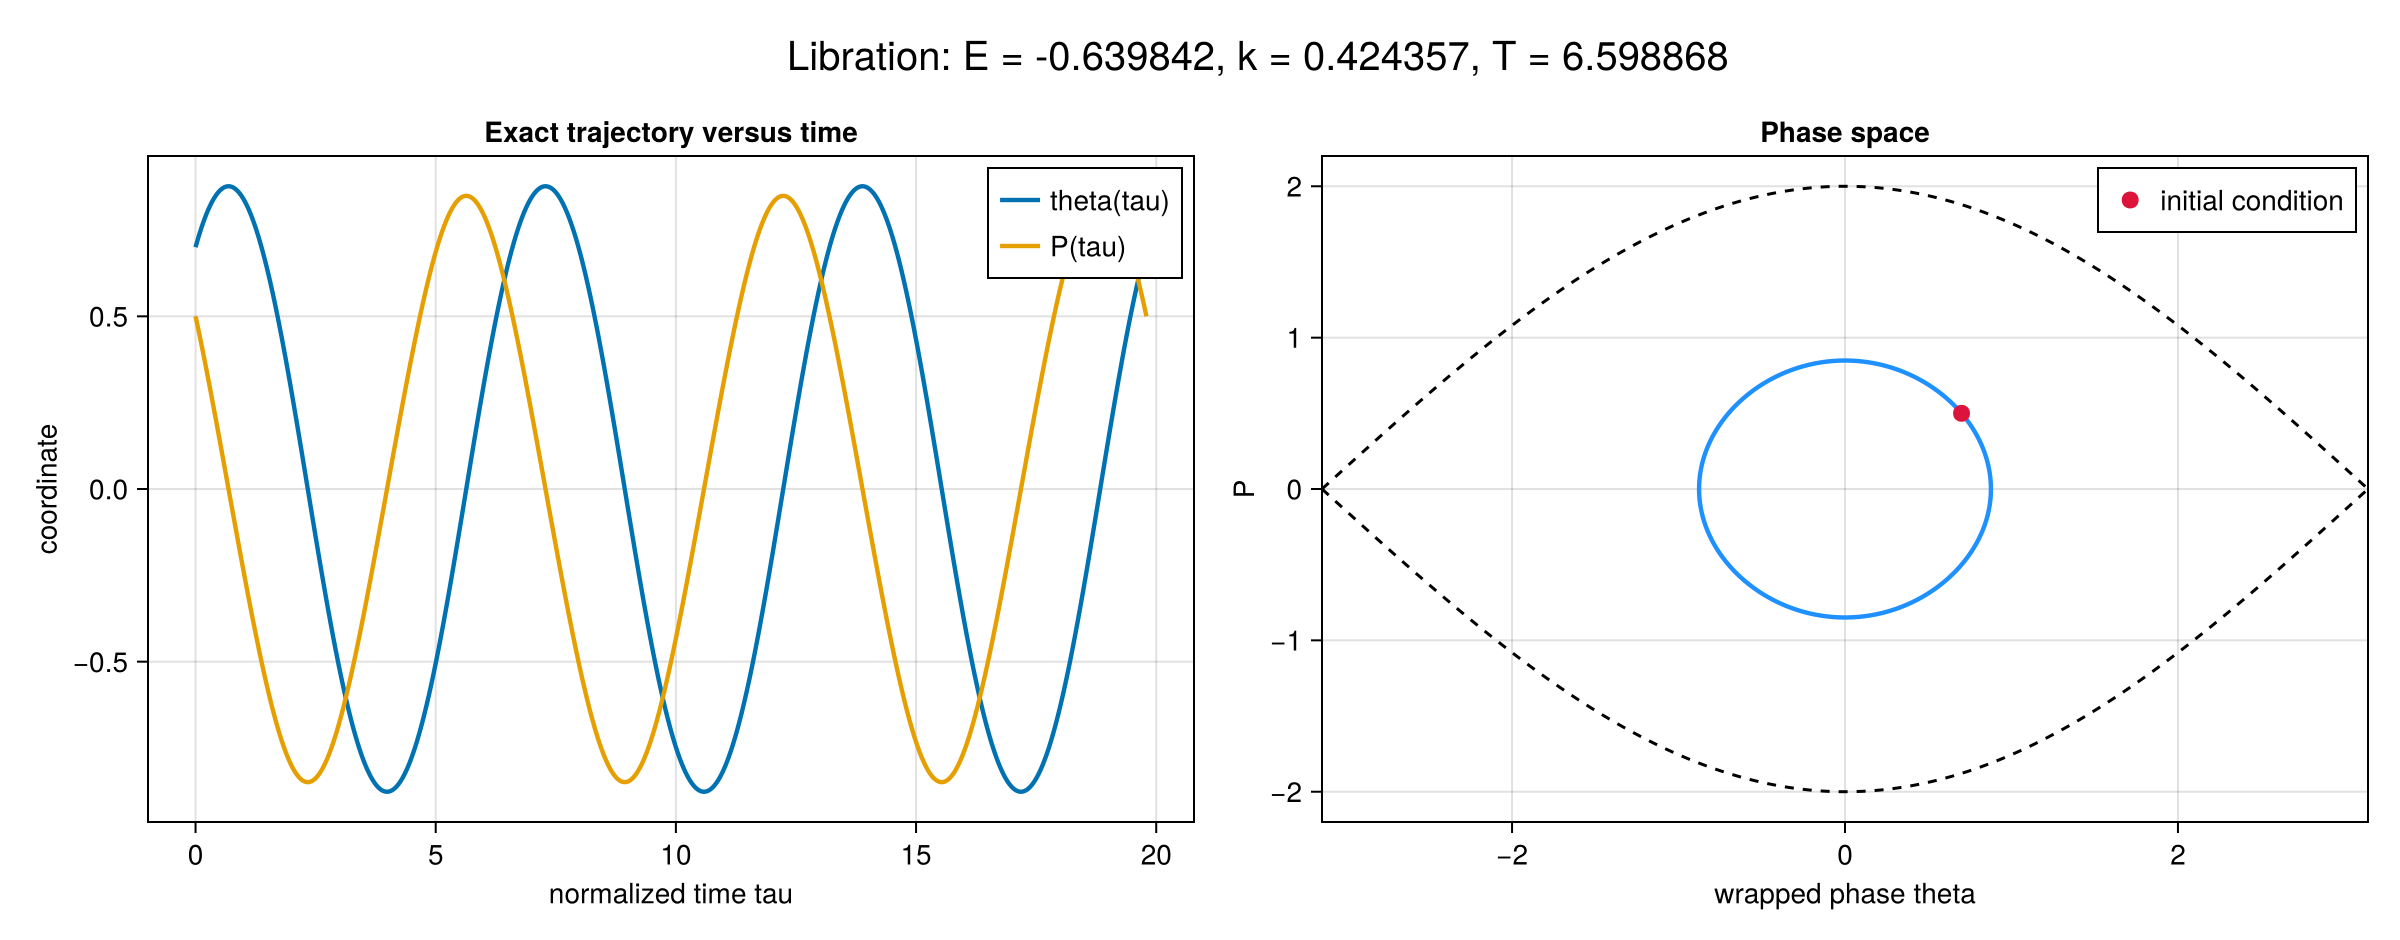

CairoMakie.Screen{IMAGE}


In [7]:
single_particle_figure = plot_pendulum_solution(sol, theta0, P0)
display(single_particle_figure)

In [12]:
# ## 7. Verification
#
# These tests check initial conditions and conservation of the Hamiltonian for
# all analytical branches.  Run this cell before changing the formulas.

# %%
@testset "Exact one-RF pendulum solution" begin
    test_cases = [
        ("Libration", 0.7, 0.5, range(0.0, 25.0; length=3000)),
        ("Rotation", 0.3, 2.4, range(0.0, 15.0; length=3000)),
        ("Rotation", -0.4, -2.3, range(0.0, 15.0; length=3000)),
        ("Separatrix", 0.0, 2.0, range(-8.0, 8.0; length=3000)),
        ("Stable fixed point", 0.0, 0.0, range(0.0, 10.0; length=100)),
        ("Unstable fixed point", pi, 0.0, range(0.0, 10.0; length=100)),
    ]

    for (expected_motion, theta_initial, P_initial, tau_test) in test_cases
        test_solution = pendulum_solution(theta_initial, P_initial)
        theta_test = test_solution.theta(tau_test)
        P_test = test_solution.momentum(tau_test)
        energy_test = pendulum_energy.(theta_test, P_test)

        @test test_solution.motion == expected_motion
        @test isapprox(test_solution.theta(0.0), theta_initial; atol=2e-10)
        @test isapprox(test_solution.momentum(0.0), P_initial; atol=2e-10)
        @test maximum(abs.(energy_test .- test_solution.energy)) < 1e-9
    end

    example_solution = pendulum_solution(0.7, 0.5)
    @test isapprox(example_solution.energy, -0.6398421872844885; atol=1e-10)
    @test isapprox(example_solution.modulus, 0.4243570505580232; atol=1e-10)
    @test isapprox(example_solution.period, 6.598867637727874; atol=1e-10)
end

Test Summary:                  | Pass  Total  Time
Exact one-RF pendulum solution |   27     27  0.0s


Test.DefaultTestSet("Exact one-RF pendulum solution", Any[], 27, false, false, true, 1.785788747906244e9, 1.78578874791163e9, false, "In[12]", Xoshiro(0xdf82ecaf4b2fcfbc, 0xbf6e26a9fa071bc9, 0xc0e21a48b2f03ea3, 0x65d1b62a42f4ff46, 0xaaf3df408ca95730))

In [13]:
# ## 8. Optional: an analytically evolved macroparticle bunch
#
# This is still entirely analytical: one exact solution is constructed for each
# initial condition.  Set `n_particles = 5000` to match the Python notebook, or
# start smaller while compiling the notebook for the first time.

# %%
function analytical_ensemble(
    theta0_values::AbstractVector,
    P0_values::AbstractVector,
    tau_grid::AbstractVector,
)
    length(theta0_values) == length(P0_values) ||
        throw(ArgumentError("theta0_values and P0_values must have equal length"))

    n_times = length(tau_grid)
    n_particles = length(theta0_values)
    theta_over_time = Matrix{Float64}(undef, n_times, n_particles)
    P_over_time = Matrix{Float64}(undef, n_times, n_particles)
    motions = Vector{String}(undef, n_particles)

    for particle in eachindex(theta0_values, P0_values)
        particle_solution = pendulum_solution(
            theta0_values[particle],
            P0_values[particle],
        )
        theta_over_time[:, particle] .= particle_solution.theta(tau_grid)
        P_over_time[:, particle] .= particle_solution.momentum(tau_grid)
        motions[particle] = particle_solution.motion
    end

    return (
        theta=theta_over_time,
        momentum=P_over_time,
        motion=motions,
    )
end


function histogram_over_time(
    values::AbstractMatrix,
    bin_edges::AbstractVector;
    wrap_phase::Bool=false,
)
    n_times = size(values, 1)
    n_bins = length(bin_edges) - 1
    counts = zeros(Int, n_times, n_bins)

    for time_index in axes(values, 1), particle_index in axes(values, 2)
        value = values[time_index, particle_index]
        value = wrap_phase ? wrap_angle(value) : value
        bin = searchsortedlast(bin_edges, value)

        # Include a value exactly equal to the final edge in the final bin.
        if bin == length(bin_edges) && value == bin_edges[end]
            bin -= 1
        end

        if 1 <= bin <= n_bins
            counts[time_index, bin] += 1
        end
    end

    return counts
end

histogram_over_time (generic function with 1 method)

In [45]:
rng = MersenneTwister(2)
n_particles = 100000                 # increase to 5000 when desired
theta0_bunch = (pi / 6.0) .* randn(rng, n_particles).+0.05
P0_bunch = sqrt(0.1) .* randn(rng, n_particles).+0.5
tau_bunch = collect(range(0.0, 10.0; length=500))

ensemble = analytical_ensemble(theta0_bunch, P0_bunch, tau_bunch)

phase_edges = collect(range(-pi, pi; length=151))
phase_centers = (phase_edges[1:end-1] .+ phase_edges[2:end]) ./ 2.0
phase_histograms = histogram_over_time(
    ensemble.theta,
    phase_edges;
    wrap_phase=true,
)


500×150 Matrix{Int64}:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0   

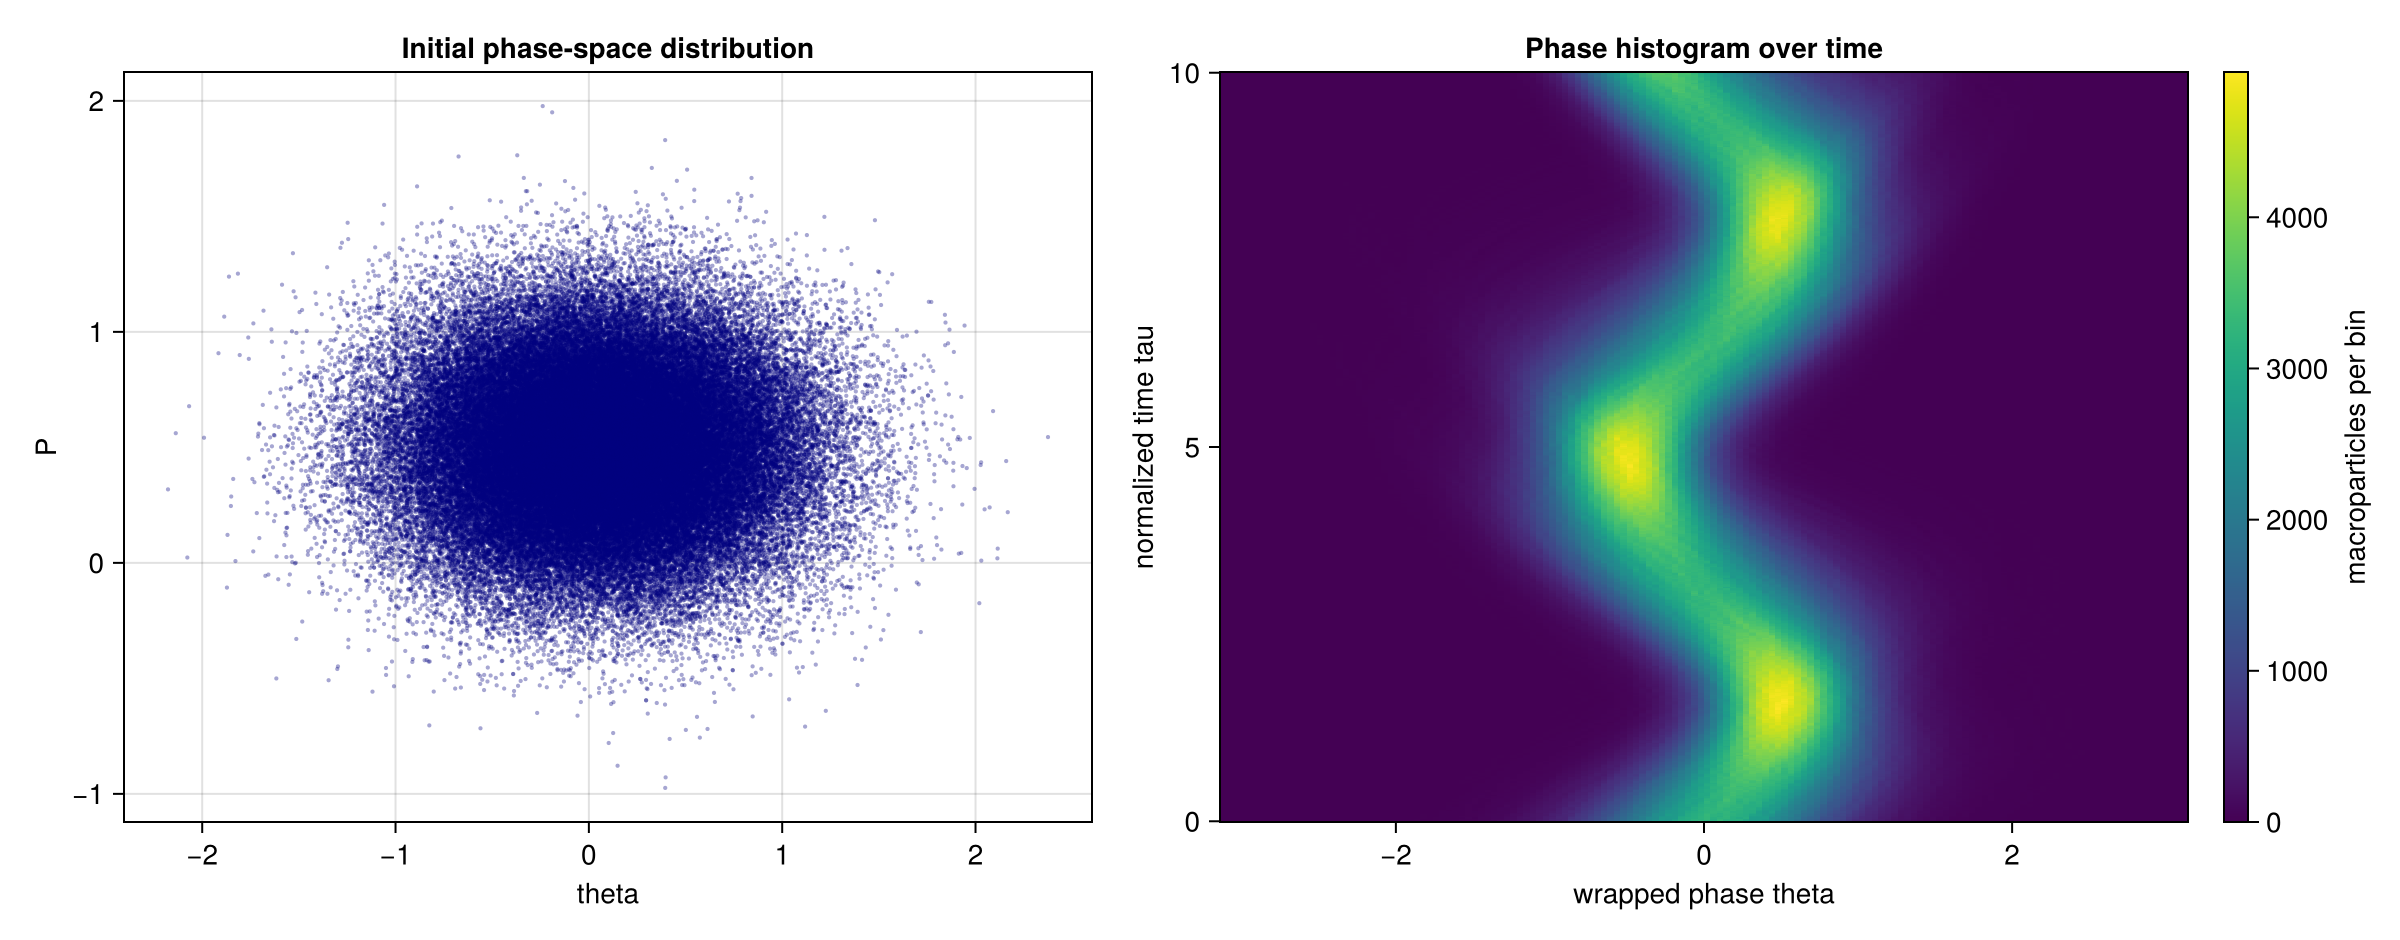

CairoMakie.Screen{IMAGE}


In [46]:
ensemble_figure = Figure(size=(1200, 470))

axis_initial = Axis(
    ensemble_figure[1, 1];
    xlabel="theta",
    ylabel="P",
    title="Initial phase-space distribution",
)
scatter!(axis_initial, theta0_bunch, P0_bunch; markersize=3, color=(:navy, 0.35))

axis_histogram = Axis(
    ensemble_figure[1, 2];
    xlabel="wrapped phase theta",
    ylabel="normalized time tau",
    title="Phase histogram over time",
)
heatmap_object = heatmap!(
    axis_histogram,
    phase_centers,
    tau_bunch,
    permutedims(phase_histograms);
    colormap=:viridis,
)
Colorbar(ensemble_figure[1, 3], heatmap_object; label="macroparticles per bin")

display(ensemble_figure)


In [27]:
# ## 9. General single-RF Hamiltonian contour
#
# This reproduces the general RF Hamiltonian from the Python notebook.  The
# exact Jacobi solution above corresponds to the stationary normalized
# pendulum.  A nonzero accelerating synchronous phase introduces the tilted
# potential and is a separate analytical/numerical extension.

# %%
function rf_hamiltonian(Pphi::Real, phi::Real, psi_s::Real, omega::Real)
    abs(cos(psi_s)) > eps(Float64) ||
        throw(ArgumentError("cos(psi_s) is too close to zero"))

    potential = omega^2 / cos(psi_s) * (
        cos(psi_s + phi) - cos(psi_s) + phi * sin(psi_s)
    )
    return 0.5 * Pphi^2 + potential
end


function plot_rf_hamiltonian_contour(;
    psi_s::Real=pi,
    omega::Real=1.0,
    phi_limits=(-2*pi,2*pi),
    P_limits=(-3.0, 3.0),
    grid_points::Integer=500,
    levels::Integer=30,
)
    phi_grid = collect(range(phi_limits[1], phi_limits[2]; length=grid_points))
    P_grid = collect(range(P_limits[1], P_limits[2]; length=grid_points))

    # CairoMakie expects the first matrix index to follow the x coordinate.
    H = [rf_hamiltonian(P, phi, psi_s, omega) for phi in phi_grid, P in P_grid]

    figure = Figure(size=(1000, 600))
    axis = Axis(
        figure[1, 1];
        xlabel="phase phi",
        ylabel="canonical momentum P_phi",
        title=@sprintf("Single-RF Hamiltonian: psi_s = %.4f, omega = %.4f", psi_s, omega),
    )
    contour_object = contourf!(
        axis,
        phi_grid,
        P_grid,
        H;
        levels=levels,
        colormap=:viridis,
    )
    contour!(axis, phi_grid, P_grid, H; levels=levels, color=(:black, 0.28), linewidth=0.5)
    Colorbar(figure[1, 2], contour_object; label="Hamiltonian")

    return figure
end

plot_rf_hamiltonian_contour (generic function with 1 method)

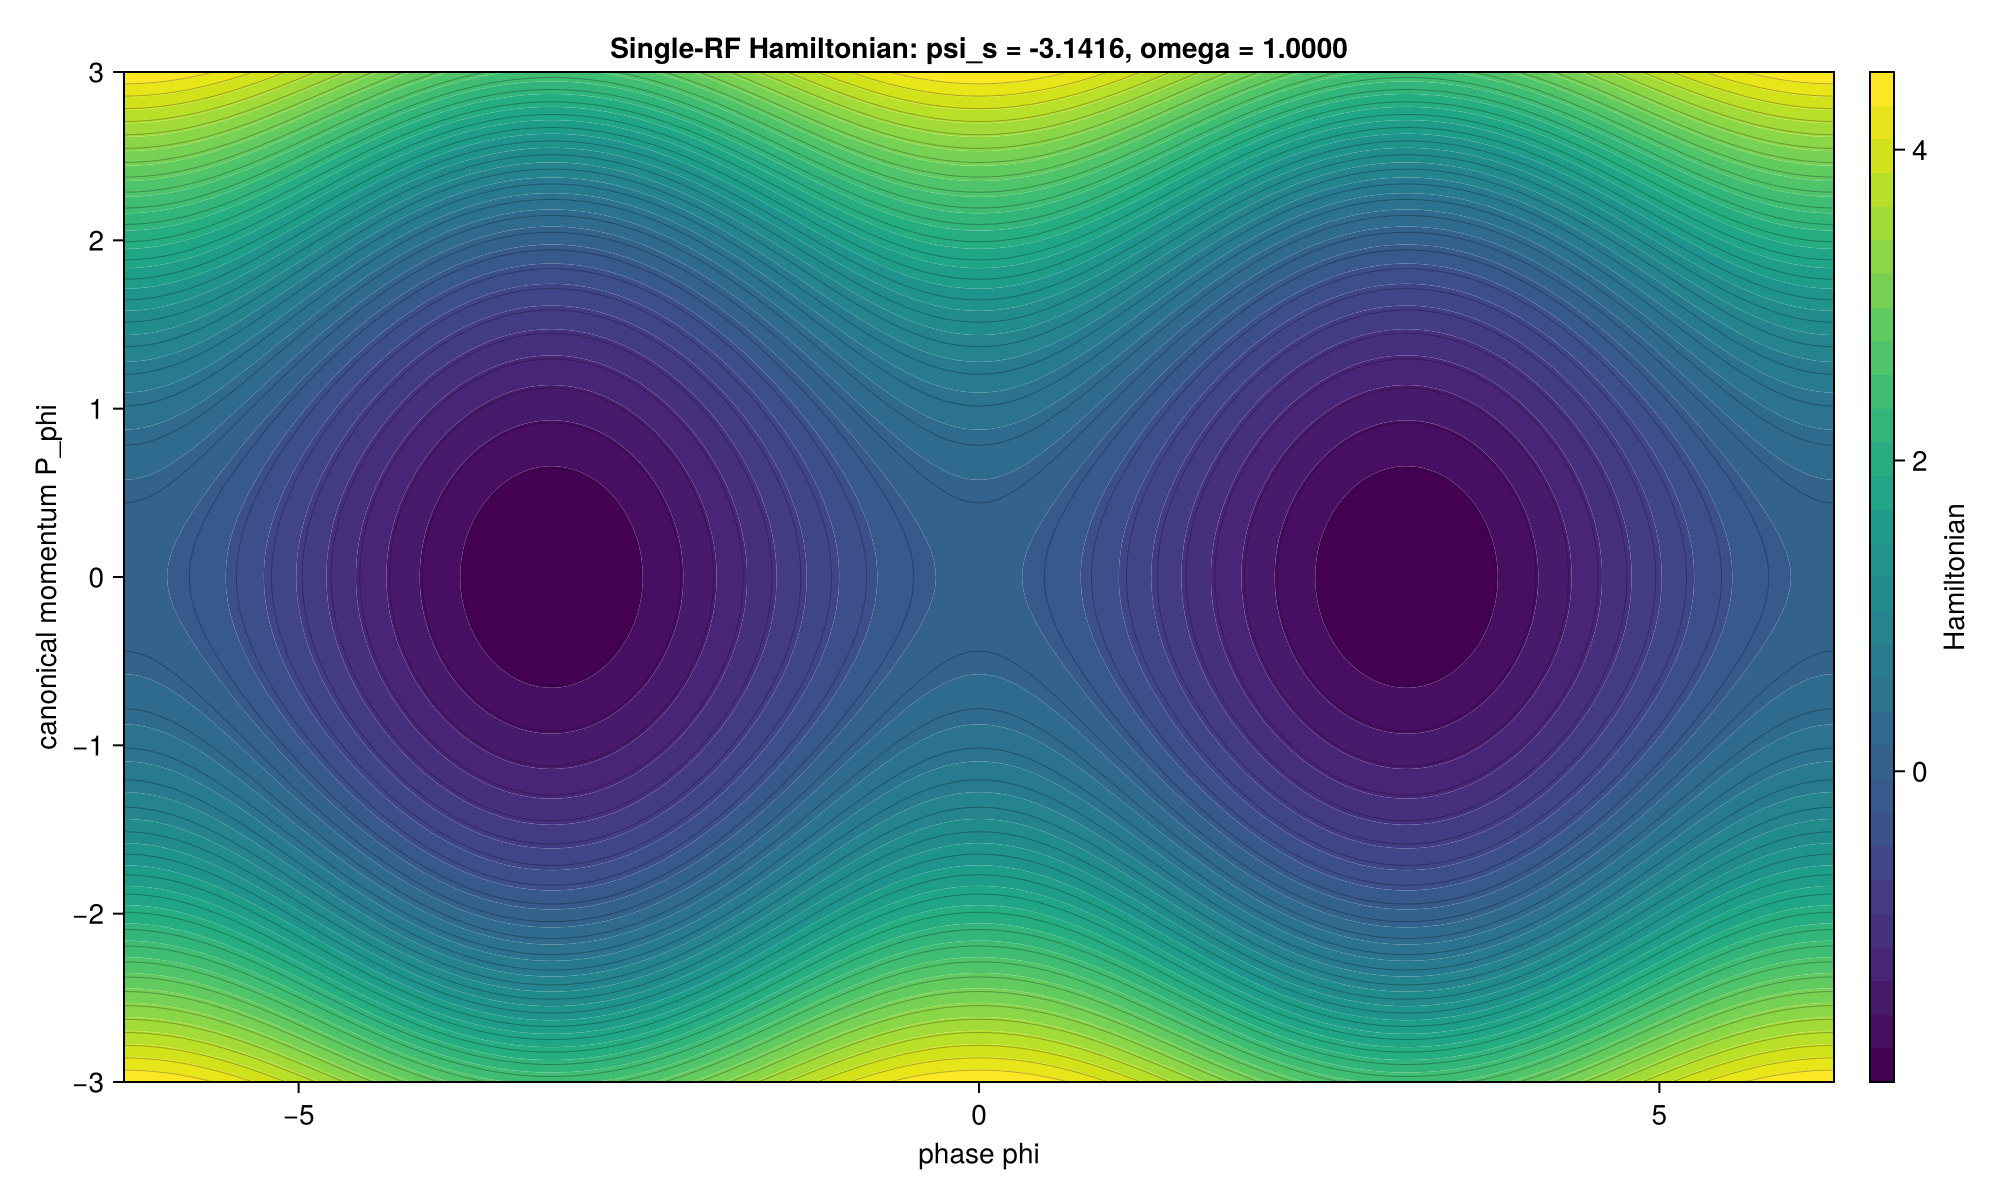

CairoMakie.Screen{IMAGE}


In [28]:
rf_contour_figure = plot_rf_hamiltonian_contour(psi_s=-pi, omega=1.0)
display(rf_contour_figure)


In [47]:
# ## 10. Map the normalized solution to BLonD variables
#
# We now specialize to a stationary, single-harmonic RF bucket with constant
# machine parameters.  BLonD uses
#
#     Delta t = particle arrival time - reference-clock arrival time,
#     Delta E = particle total energy - synchronous total energy.
#
# Let
#
#     phi     = omega_rf Delta t + phi_rf,
#     phi_s   = omega_rf Delta t_s + phi_rf,
#     theta   = phi - phi_s = omega_rf (Delta t - Delta t_s).
#
# For a stationary bucket, sin(phi_s) = 0 and stability requires
#
#     eta0 * V * cos(phi_s) < 0.
#
# The small-amplitude synchrotron tune is
#
#     Q_s = sqrt[-h eta0 V cos(phi_s) / (2*pi beta_s^2 E_s)],
#
# and the normalized time and momentum used by the exact solution are
#
#     tau = 2*pi*Q_s*(N-N0) + tau0,
#     P   = h*eta0*Delta E / (beta_s^2*E_s*Q_s).
#
# Therefore, below transition (eta0 < 0), positive P corresponds to negative
# Delta E in the BLonD convention.  This is not an error: it follows from
# d(Delta t)/dt = eta0*Delta E/(beta_s^2 E_s).

# %%
"""Constant machine parameters for a stationary single-RF BLonD bucket."""
struct BlondSingleRFParameters
    harmonic::Int
    f_rev_hz::Float64
    eta0::Float64
    beta_s::Float64
    E_s_eV::Float64
    rf_kick_eV::Float64
    phi_s::Float64
    delta_t_s::Float64
end


function BlondSingleRFParameters(;
    harmonic::Integer,
    f_rev_hz::Real,
    eta0::Real,
    beta_s::Real,
    E_s_eV::Real,
    rf_kick_eV::Real,
    phi_s::Real=0.0,
    delta_t_s::Real=0.0,
)
    parameters = BlondSingleRFParameters(
        Int(harmonic),
        float(f_rev_hz),
        float(eta0),
        float(beta_s),
        float(E_s_eV),
        float(rf_kick_eV),
        float(phi_s),
        float(delta_t_s),
    )

    parameters.harmonic > 0 || throw(ArgumentError("harmonic must be positive"))
    parameters.f_rev_hz > 0.0 || throw(ArgumentError("f_rev_hz must be positive"))
    0.0 < parameters.beta_s <= 1.0 || throw(ArgumentError("beta_s must lie in (0,1]"))
    parameters.E_s_eV > 0.0 || throw(ArgumentError("E_s_eV must be positive"))
    parameters.rf_kick_eV != 0.0 || throw(ArgumentError("rf_kick_eV must be nonzero"))

    abs(sin(parameters.phi_s)) <= 1e-10 || throw(ArgumentError(
        "The exact pendulum mapping in this section requires a stationary " *
        "bucket: sin(phi_s) must be zero.",
    ))

    stability_product = parameters.eta0 * parameters.rf_kick_eV * cos(parameters.phi_s)
    stability_product < 0.0 || throw(ArgumentError(
        "The synchronous phase is unstable: eta0*rf_kick_eV*cos(phi_s) must be negative.",
    ))

    return parameters
end


revolution_period(parameters::BlondSingleRFParameters) = 1.0 / parameters.f_rev_hz
omega0(parameters::BlondSingleRFParameters) = 2pi * parameters.f_rev_hz
omega_rf(parameters::BlondSingleRFParameters) = parameters.harmonic * omega0(parameters)

"""BLonD RF phase at Delta t = 0."""
phi_rf(parameters::BlondSingleRFParameters) =
    parameters.phi_s - omega_rf(parameters) * parameters.delta_t_s

"""Small-amplitude synchrotron tune Q_s in oscillations per turn."""
function synchrotron_tune(parameters::BlondSingleRFParameters)
    tune_squared = -parameters.harmonic * parameters.eta0 *
        parameters.rf_kick_eV * cos(parameters.phi_s) /
        (2pi * parameters.beta_s^2 * parameters.E_s_eV)
    return sqrt(tune_squared)
end

"""Small-amplitude synchrotron angular frequency in rad/s."""
omega_s(parameters::BlondSingleRFParameters) =
    synchrotron_tune(parameters) * omega0(parameters)

"""Small-amplitude synchrotron period in turns."""
synchrotron_period_turns(parameters::BlondSingleRFParameters) =
    1.0 / synchrotron_tune(parameters)

"""Positive magnitude of the energy scale multiplying |P|, in eV."""
delta_energy_scale(parameters::BlondSingleRFParameters) =
    parameters.beta_s^2 * parameters.E_s_eV * synchrotron_tune(parameters) /
    (parameters.harmonic * abs(parameters.eta0))

"""Stationary bucket half-height at theta = 0, in eV."""
bucket_half_height_eV(parameters::BlondSingleRFParameters) =
    2.0 * delta_energy_scale(parameters)

"""Stationary bucket half-width in arrival time, in seconds."""
bucket_half_width_s(parameters::BlondSingleRFParameters) =
    pi / omega_rf(parameters)

# %% [markdown]
# ### Forward and inverse coordinate maps

# %%
"""Convert BLonD arrival-time offset Delta t [s] to normalized phase theta."""
theta_from_delta_t(delta_t, parameters::BlondSingleRFParameters) =
    omega_rf(parameters) .* (delta_t .- parameters.delta_t_s)

"""Convert normalized phase theta to BLonD arrival-time offset Delta t [s]."""
delta_t_from_theta(theta, parameters::BlondSingleRFParameters) =
    parameters.delta_t_s .+ theta ./ omega_rf(parameters)

"""Convert BLonD energy offset Delta E [eV] to normalized momentum P."""
P_from_delta_energy(delta_E, parameters::BlondSingleRFParameters) =
    parameters.harmonic * parameters.eta0 .* delta_E ./
    (parameters.beta_s^2 * parameters.E_s_eV * synchrotron_tune(parameters))

"""Convert normalized momentum P to BLonD energy offset Delta E [eV]."""
delta_energy_from_P(P, parameters::BlondSingleRFParameters) =
    parameters.beta_s^2 * parameters.E_s_eV * synchrotron_tune(parameters) .* P ./
    (parameters.harmonic * parameters.eta0)

"""Convert continuous turn coordinate N to normalized time tau."""
tau_from_turn(N, parameters::BlondSingleRFParameters; N0=0.0, tau0=0.0) =
    tau0 .+ 2pi * synchrotron_tune(parameters) .* (N .- N0)

"""Convert normalized time tau to continuous turn coordinate N."""
turn_from_tau(tau, parameters::BlondSingleRFParameters; N0=0.0, tau0=0.0) =
    N0 .+ (tau .- tau0) ./ (2pi * synchrotron_tune(parameters))

"""
Evaluate an exact normalized trajectory in BLonD coordinates.

`N` can be a scalar or an array.  The analytical solution is initialized at
`tau0`, corresponding to turn `N0`.
"""
function evaluate_in_blond_coordinates(
    solution::PendulumSolution,
    N,
    parameters::BlondSingleRFParameters;
    N0::Real=0.0,
    tau0::Real=0.0,
)
    tau = tau_from_turn(N, parameters; N0=N0, tau0=tau0)
    theta = solution.theta(tau)
    P = solution.momentum(tau)

    return (
        turn=N,
        tau=tau,
        theta=theta,
        P=P,
        delta_t=delta_t_from_theta(theta, parameters),
        delta_E=delta_energy_from_P(P, parameters),
    )
end

"""
Construct the exact pendulum solution from BLonD initial coordinates.

The returned solution uses `tau0=0`; evaluate it with
`evaluate_in_blond_coordinates(...; N0=N0, tau0=0)`.
"""
function pendulum_solution_from_blond(
    delta_t0::Real,
    delta_E0::Real,
    parameters::BlondSingleRFParameters,
)
    theta0 = theta_from_delta_t(delta_t0, parameters)
    P0 = P_from_delta_energy(delta_E0, parameters)
    return pendulum_solution(theta0, P0; tau0=0.0)
end

# %% [markdown]
# ### Hamiltonian consistency
#
# For a stationary bucket, the BLonD continuous Hamiltonian is
#
#     H_B = eta0 (Delta E)^2/(2 beta_s^2 E_s)
#           + V/(2*pi*h) [cos(phi_s + theta) - cos(phi_s)].
#
# It is related to the normalized pendulum energy by
#
#     H_B = -V cos(phi_s)/(2*pi*h) * (E_normalized + 1).

# %%
function blond_stationary_hamiltonian(
    delta_t,
    delta_E,
    parameters::BlondSingleRFParameters,
)
    particle_phase = omega_rf(parameters) .* delta_t .+ phi_rf(parameters)
    kinetic = parameters.eta0 .* delta_E.^2 ./
        (2.0 * parameters.beta_s^2 * parameters.E_s_eV)
    potential = parameters.rf_kick_eV ./ (2pi * parameters.harmonic) .* (
        cos.(particle_phase) .- cos(parameters.phi_s)
    )
    return kinetic .+ potential
end


function normalized_energy_from_blond(
    delta_t,
    delta_E,
    parameters::BlondSingleRFParameters,
)
    H_blond = blond_stationary_hamiltonian(delta_t, delta_E, parameters)
    scale = parameters.rf_kick_eV * cos(parameters.phi_s) /
        (2pi * parameters.harmonic)
    return -H_blond ./ scale .- 1.0
end

normalized_energy_from_blond (generic function with 1 method)

In [51]:
# ## 11. Recycler-like example: 0 to 250 turns
#
# The values below are representative, not a substitute for the exact values in
# your BLonD `Ring` and `RFStation` objects.  In particular, replace `eta0`,
# `f_rev_hz`, and `rf_kick_eV` with the values used in the simulation you want
# to compare against.

# %%
const PROTON_MASS_EV = 938.2720813e6

recycler_kinetic_energy_eV = 8.0e9
recycler_total_energy_eV = recycler_kinetic_energy_eV + PROTON_MASS_EV
recycler_gamma = recycler_total_energy_eV / PROTON_MASS_EV
recycler_beta = sqrt(1.0 - 1.0 / recycler_gamma^2)

recycler_parameters = BlondSingleRFParameters(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.6e-3,
    beta_s=recycler_beta,
    E_s_eV=recycler_total_energy_eV,
    rf_kick_eV=80.0e3,
    phi_s=0.0,
    delta_t_s=0.0,
)

@printf("Q_s                         = %.7f\n", synchrotron_tune(recycler_parameters))
@printf("synchrotron period          = %.2f turns\n", synchrotron_period_turns(recycler_parameters))
@printf("bucket half-width           = %.3f ns\n", bucket_half_width_s(recycler_parameters) * 1e9)
@printf("bucket half-height          = %.3f MeV\n", bucket_half_height_eV(recycler_parameters) * 1e-6)
@printf("one radian of RF phase      = %.3f ns\n", 1e9 / omega_rf(recycler_parameters))

# Initial condition in the same variables used by a BLonD beam object.
delta_t0_blond = 2.0e-9       # seconds
delta_E0_blond = 0.5e6        # eV

physical_solution = pendulum_solution_from_blond(
    delta_t0_blond,
    delta_E0_blond,
    recycler_parameters,
)

turn_grid = collect(range(0.0, 250.0; length=2501))
physical_trajectory = evaluate_in_blond_coordinates(
    physical_solution,
    turn_grid,
    recycler_parameters,
)

# %%
function plot_blond_trajectory(
    trajectory,
    parameters::BlondSingleRFParameters;
    delta_t0=nothing,
    delta_E0=nothing,
)
    figure = Figure(size=(1450, 440))

    axis_time = Axis(
        figure[1, 1];
        xlabel="turn N",
        ylabel="Delta t [ns]",
        title="Arrival-time motion",
    )
    lines!(axis_time, trajectory.turn, trajectory.delta_t .* 1e9; linewidth=2.2)

    axis_energy = Axis(
        figure[1, 2];
        xlabel="turn N",
        ylabel="Delta E [MeV]",
        title="Energy motion",
    )
    lines!(axis_energy, trajectory.turn, trajectory.delta_E .* 1e-6; linewidth=2.2)

    axis_phase = Axis(
        figure[1, 3];
        xlabel="Delta t [ns]",
        ylabel="Delta E [MeV]",
        title="Physical longitudinal phase space",
    )

    theta_sep = range(-pi, pi; length=1200)
    P_sep = 2.0 .* cos.(theta_sep ./ 2.0)
    delta_t_sep = delta_t_from_theta(theta_sep, parameters) .* 1e9
    delta_E_sep_upper = delta_energy_from_P(P_sep, parameters) .* 1e-6
    delta_E_sep_lower = delta_energy_from_P(-P_sep, parameters) .* 1e-6

    lines!(axis_phase, delta_t_sep, delta_E_sep_upper; color=:black, linestyle=:dash)
    lines!(axis_phase, delta_t_sep, delta_E_sep_lower; color=:black, linestyle=:dash)
    lines!(
        axis_phase,
        trajectory.delta_t .* 1e9,
        trajectory.delta_E .* 1e-6;
        color=:dodgerblue,
        linewidth=2.2,
    )

    if !isnothing(delta_t0) && !isnothing(delta_E0)
        scatter!(
            axis_phase,
            [delta_t0 * 1e9],
            [delta_E0 * 1e-6];
            color=:crimson,
            markersize=12,
        )
    end

    return figure
end


Q_s                         = 0.0026988
synchrotron period          = 370.53 turns
bucket half-width           = 9.469 ns
bucket half-height          = 9.436 MeV
one radian of RF phase      = 3.014 ns


plot_blond_trajectory (generic function with 1 method)

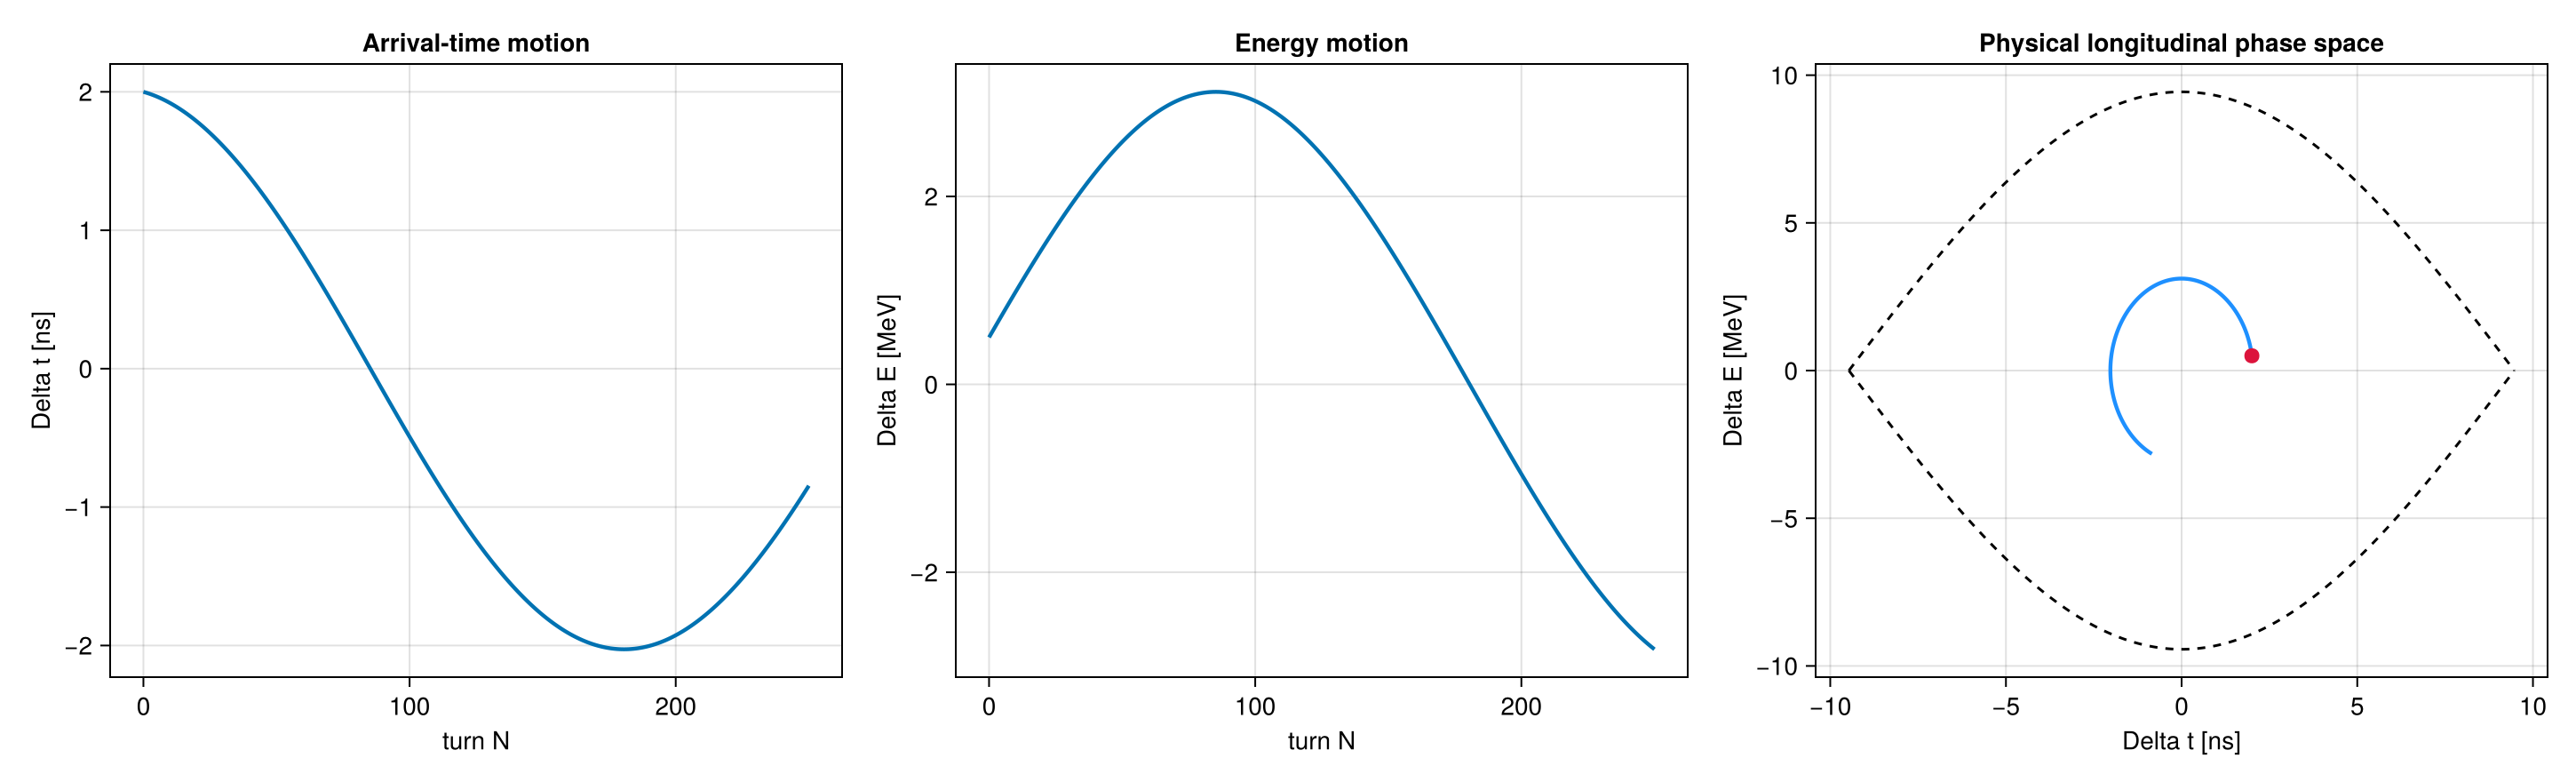

CairoMakie.Screen{IMAGE}


In [52]:
physical_figure = plot_blond_trajectory(
    physical_trajectory,
    recycler_parameters;
    delta_t0=delta_t0_blond,
    delta_E0=delta_E0_blond,
)
display(physical_figure)

In [53]:
# ### Mapping checks

# %%
@testset "Normalized <-> BLonD coordinate mapping" begin
    theta_check = [-2.2, -0.4, 0.0, 1.3, 2.7]
    P_check = [-1.8, -0.2, 0.0, 0.7, 1.9]
    N_check = [0.0, 17.0, 100.0, 250.0]

    delta_t_check = delta_t_from_theta(theta_check, recycler_parameters)
    delta_E_check = delta_energy_from_P(P_check, recycler_parameters)
    tau_check = tau_from_turn(N_check, recycler_parameters)

    @test theta_from_delta_t(delta_t_check, recycler_parameters) ≈ theta_check
    @test P_from_delta_energy(delta_E_check, recycler_parameters) ≈ P_check
    @test turn_from_tau(tau_check, recycler_parameters) ≈ N_check

    normalized_energy_direct = pendulum_energy.(theta_check, P_check)
    normalized_energy_mapped = normalized_energy_from_blond(
        delta_t_check,
        delta_E_check,
        recycler_parameters,
    )
    @test normalized_energy_mapped ≈ normalized_energy_direct atol=2e-12

    @test isapprox(physical_trajectory.delta_t[1], delta_t0_blond; atol=1e-18)
    @test isapprox(physical_trajectory.delta_E[1], delta_E0_blond; atol=1e-7)

    physical_energy = blond_stationary_hamiltonian(
        physical_trajectory.delta_t,
        physical_trajectory.delta_E,
        recycler_parameters,
    )
    @test maximum(abs.(physical_energy .- physical_energy[1])) < 1e-7
end


Test Summary:                           | Pass  Total  Time
Normalized <-> BLonD coordinate mapping |    7      7  0.3s


Test.DefaultTestSet("Normalized <-> BLonD coordinate mapping", Any[], 7, false, false, true, 1.785790790817781e9, 1.785790791164597e9, false, "In[53]", Xoshiro(0xdf82ecaf4b2fcfbc, 0xbf6e26a9fa071bc9, 0xc0e21a48b2f03ea3, 0x65d1b62a42f4ff46, 0xaaf3df408ca95730))

In [54]:
# Choose the physical turn grid first
turn_bunch_blond = collect(range(0.0, 250.0; length=501))
tau_bunch_blond = tau_from_turn(
    turn_bunch_blond,
    recycler_parameters,
)

# Evaluate the analytical solutions at those turns
ensemble_blond = analytical_ensemble(
    theta0_bunch,
    P0_bunch,
    tau_bunch_blond,
)

# Initial distribution in physical units
delta_t0_bunch_s = delta_t_from_theta(
    wrap_angle(theta0_bunch),
    recycler_parameters,
)

delta_E0_bunch_eV = delta_energy_from_P(
    P0_bunch,
    recycler_parameters,
)

# Wrap into one RF period before converting phase to time
theta_over_turns_wrapped = wrap_angle(ensemble_blond.theta)

delta_t_over_turns_s = delta_t_from_theta(
    theta_over_turns_wrapped,
    recycler_parameters,
)

# Histogram limits: one complete RF bucket
delta_t_half_width_s = bucket_half_width_s(recycler_parameters)

delta_t_bin_edges_s = collect(range(
    recycler_parameters.delta_t_s - delta_t_half_width_s,
    recycler_parameters.delta_t_s + delta_t_half_width_s;
    length=151,
))

delta_t_bin_centers_s =
    (delta_t_bin_edges_s[1:end-1] .+
     delta_t_bin_edges_s[2:end]) ./ 2

delta_t_histograms_over_turns = histogram_over_time(
    delta_t_over_turns_s,
    delta_t_bin_edges_s;
    wrap_phase=false,
)

501×150 Matrix{Int64}:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0   

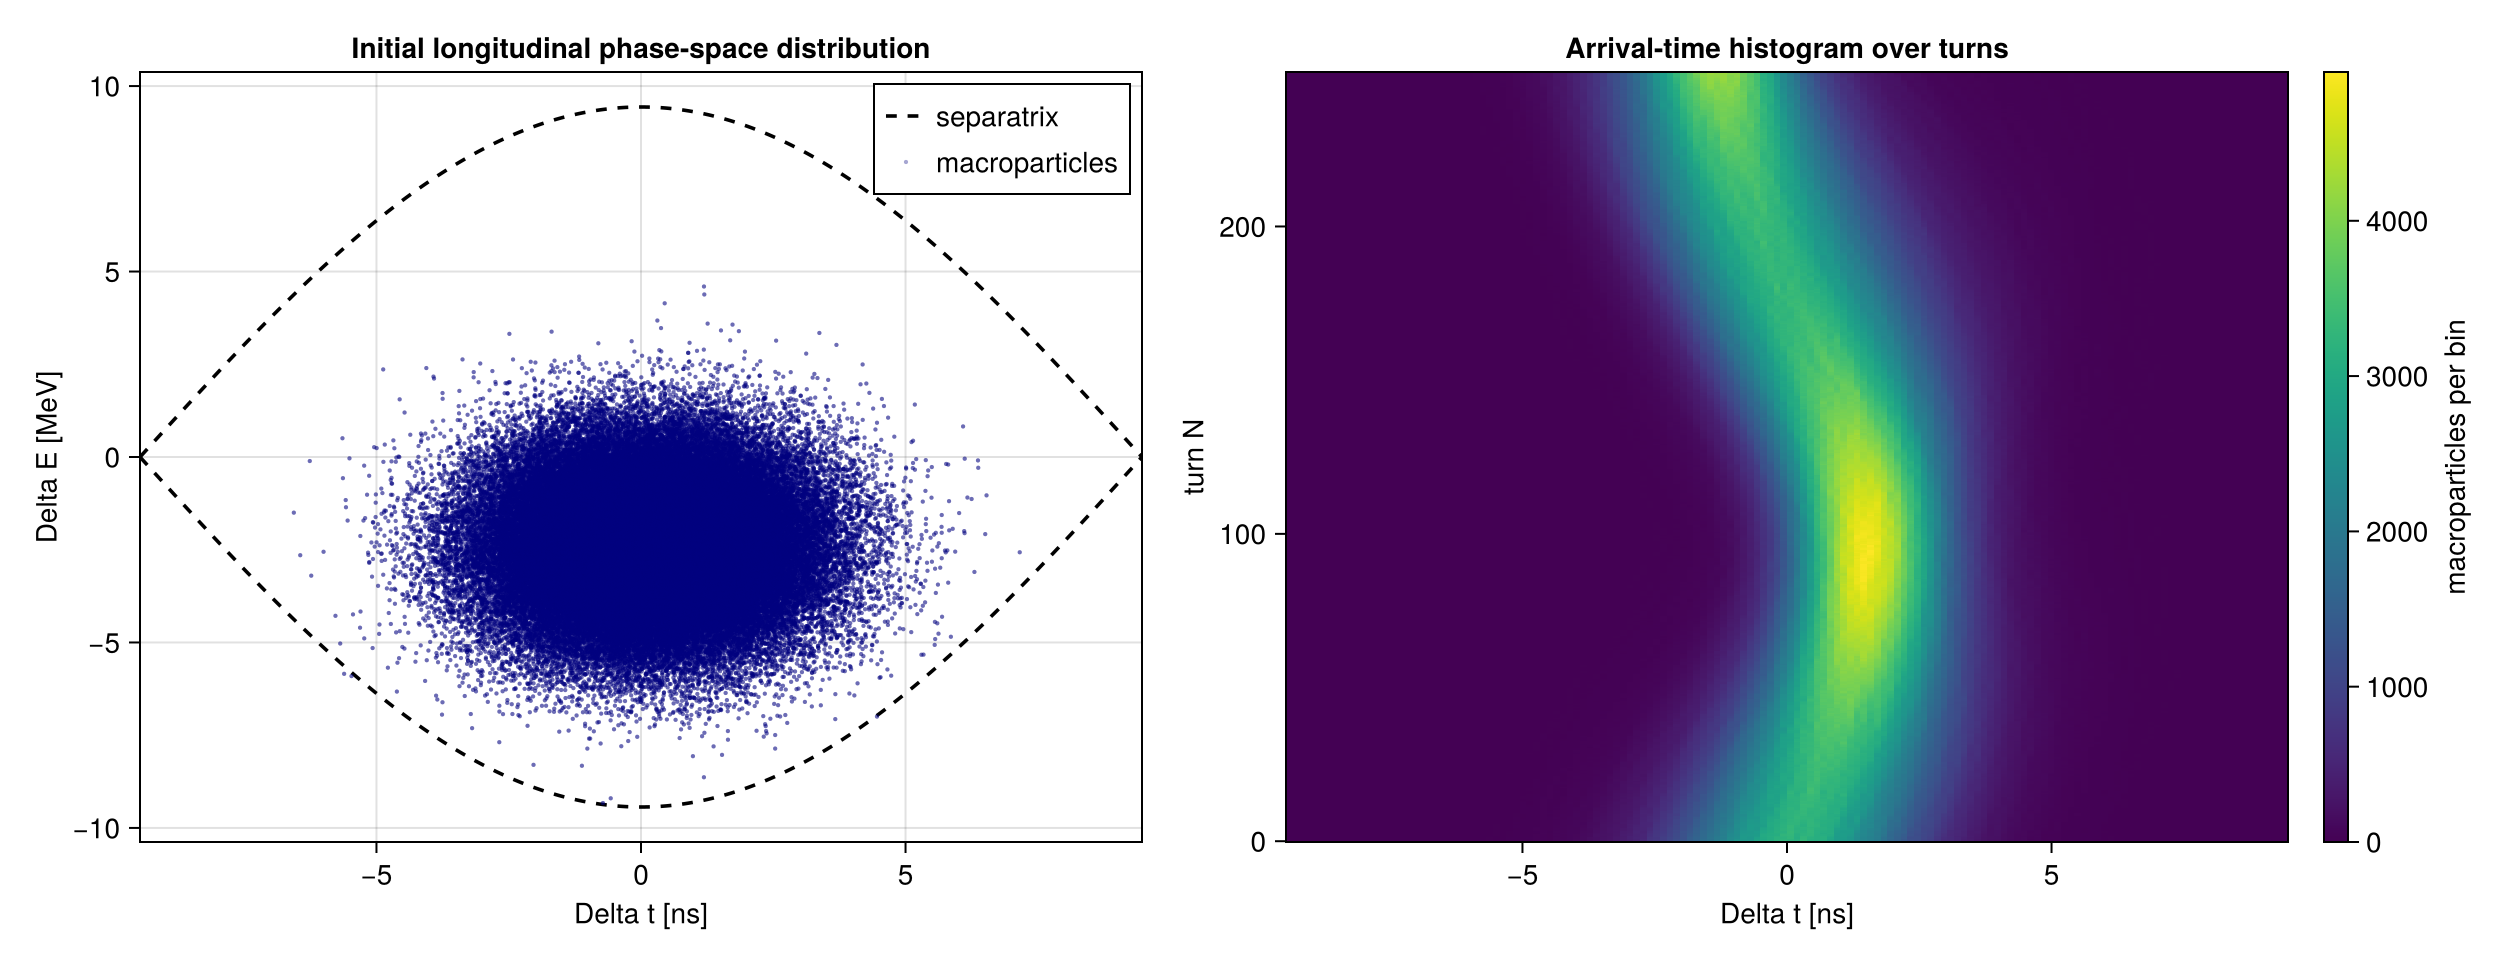

CairoMakie.Screen{IMAGE}


In [58]:
# Plot
ensemble_figure = Figure(size=(1250, 480))

axis_initial = Axis(
    ensemble_figure[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="Initial longitudinal phase-space distribution",
)


# Normalized stationary-bucket separatrix:
# P_sep = ±2*cos(theta/2),  theta ∈ [-pi, pi]
theta_sep = range(-pi, pi; length=1200)
P_sep = 2.0 .* cos.(theta_sep ./ 2.0)

# Convert both branches to BLonD coordinates
delta_t_sep_ns =
    delta_t_from_theta(theta_sep, recycler_parameters) .* 1e9

delta_E_sep_branch1_MeV =
    delta_energy_from_P(P_sep, recycler_parameters) .* 1e-6

delta_E_sep_branch2_MeV =
    delta_energy_from_P(-P_sep, recycler_parameters) .* 1e-6

# Draw separatrix
lines!(
    axis_initial,
    delta_t_sep_ns,
    delta_E_sep_branch1_MeV;
    color=:black,
    linestyle=:dash,
    linewidth=1.8,
    label="separatrix",
)

lines!(
    axis_initial,
    delta_t_sep_ns,
    delta_E_sep_branch2_MeV;
    color=:black,
    linestyle=:dash,
    linewidth=1.8,
)

# Draw particles after the separatrix
scatter!(
    axis_initial,
    delta_t0_bunch_s .* 1e9,
    delta_E0_bunch_eV .* 1e-6;
    markersize=3,
    color=(:navy, 0.35),
    label="macroparticles",
)

xlims!(
    axis_initial,
    delta_t_bin_edges_s[1] * 1e9,
    delta_t_bin_edges_s[end] * 1e9,
)

axislegend(axis_initial; position=:rt)

scatter!(
    axis_initial,
    delta_t0_bunch_s .* 1e9,
    delta_E0_bunch_eV .* 1e-6;
    markersize=3,
    color=(:navy, 0.35),
)

axis_histogram = Axis(
    ensemble_figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="turn N",
    title="Arrival-time histogram over turns",
)

heatmap_object = heatmap!(
    axis_histogram,
    delta_t_bin_centers_s .* 1e9,
    turn_bunch_blond,
    permutedims(delta_t_histograms_over_turns);
    colormap=:viridis,
)

Colorbar(
    ensemble_figure[1, 3],
    heatmap_object;
    label="macroparticles per bin",
)

display(ensemble_figure)